# 02 - Modelagem: prever quem vai cancelar

Objetivo: treinar e comparar dois modelos de classificação para o alvo `Churn` (1 = cancelou).

**Critério de escolha (decidido na etapa 01):** priorizar **recall** (pegar o máximo de clientes que realmente vão cancelar, porque perder um cliente custa mais do que oferecer um desconto à toa), olhando também a **AUC** (capacidade geral de separar quem cancela de quem fica, independente do limiar).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

df = pd.read_csv('../data/telco_tratada.csv')
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']
num = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat = [c for c in X.columns if c not in num]
X.shape, y.mean().round(3)

((7032, 19), np.float64(0.266))

## 1. Separação treino/teste

20% dos clientes ficam **guardados** e só são usados no final, para medir o desempenho em dados que o modelo nunca viu.
`stratify=y` mantém os mesmos ~26,6% de churn nos dois grupos.

In [2]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
len(X_tr), len(X_te)

(5625, 1407)

## 2. Pré-processamento e os dois modelos

- **Categorias → números:** `OneHotEncoder` cria uma coluna 0/1 para cada valor (ex.: `Contract_Two year`).
- **Numéricas → mesma escala:** `StandardScaler`, importante para a regressão logística.
- **`class_weight='balanced'`:** dá mais peso aos clientes que cancelaram, compensando o desbalanceamento (26% x 74%). Sem isso o modelo tende a "chutar que ninguém cancela" e o recall cai.

Tudo fica dentro de um `Pipeline`, assim o tratamento aprendido no treino é aplicado igual no teste (sem vazamento de dados).

In [3]:
prep = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
])
modelos = {
    'Regressão Logística': Pipeline([('prep', prep), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))]),
    'Random Forest': Pipeline([('prep', prep), ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1))]),
}

## 3. Validação cruzada (só no treino)

Treina e avalia 5 vezes, cada vez com uma parte diferente do treino como validação. A média mostra o desempenho esperado e o desvio mostra se ele é estável.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
linhas = []
for nome, m in modelos.items():
    r = cross_validate(m, X_tr, y_tr, cv=cv, scoring=['recall', 'precision', 'f1', 'roc_auc'])
    linhas.append({'modelo': nome, **{k[5:]: f"{r[k].mean():.3f} ± {r[k].std():.3f}" for k in r if k.startswith('test_')}})
pd.DataFrame(linhas).set_index('modelo')

,recall,precision,f1,roc_auc
modelo,,,,
Regressão Logística,0.802 ± 0.014,0.522 ± 0.007,0.632 ± 0.007,0.846 ± 0.005
Random Forest,0.769 ± 0.019,0.543 ± 0.006,0.636 ± 0.008,0.847 ± 0.005


## 4. Avaliação final no conjunto de teste (dados nunca vistos)

===== Regressão Logística | AUC = 0.835
              precision    recall  f1-score   support

        Fica      0.905     0.700     0.789      1033
     Cancela      0.490     0.797     0.607       374

    accuracy                          0.726      1407
   macro avg      0.698     0.748     0.698      1407
weighted avg      0.795     0.726     0.741      1407



===== Random Forest | AUC = 0.833
              precision    recall  f1-score   support

        Fica      0.903     0.736     0.811      1033
     Cancela      0.517     0.781     0.622       374

    accuracy                          0.748      1407
   macro avg      0.710     0.758     0.716      1407
weighted avg      0.800     0.748     0.761      1407



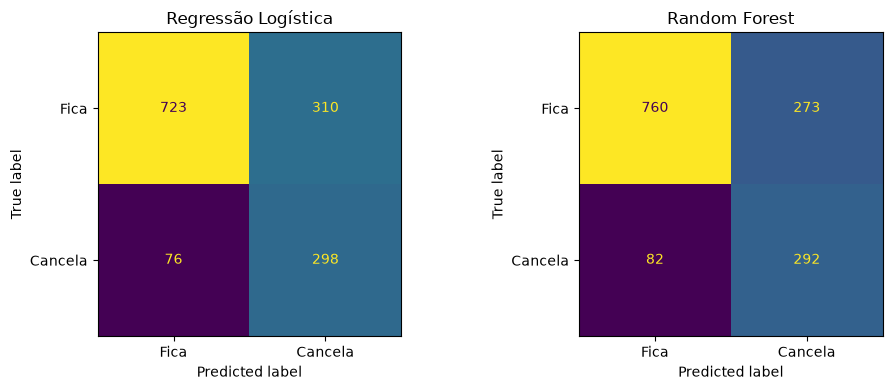

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nome, m) in zip(axes, modelos.items()):
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    print(f'===== {nome} | AUC = {roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]):.3f}')
    print(classification_report(y_te, pred, target_names=['Fica', 'Cancela'], digits=3))
    ConfusionMatrixDisplay.from_predictions(y_te, pred, display_labels=['Fica', 'Cancela'], ax=ax, colorbar=False)
    ax.set_title(nome)
plt.tight_layout(); plt.show()

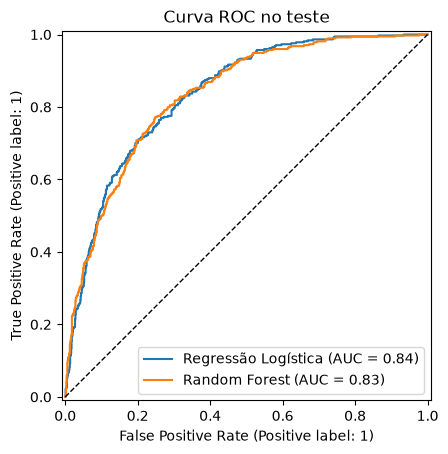

In [6]:
ax = plt.gca()
for nome, m in modelos.items():
    RocCurveDisplay.from_estimator(m, X_te, y_te, name=nome, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=1); ax.set_title('Curva ROC no teste'); plt.show()

## 5. O que mais pesa no churn?

Na regressão logística, coeficiente **positivo** aumenta a chance de cancelar e **negativo** diminui (variáveis já na mesma escala).

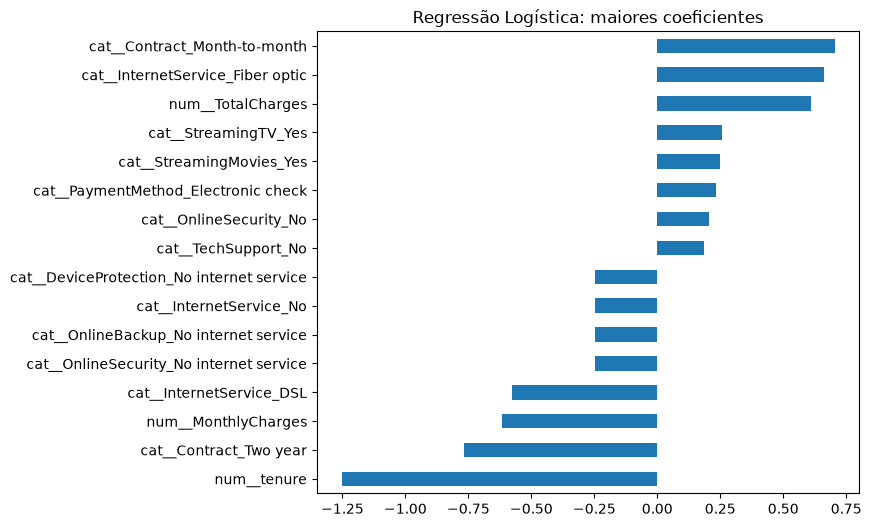

In [7]:
lr = modelos['Regressão Logística']
nomes = lr.named_steps['prep'].get_feature_names_out()
coef = pd.Series(lr.named_steps['clf'].coef_[0], index=nomes).sort_values()
pd.concat([coef.head(8), coef.tail(8)]).plot.barh(figsize=(7, 6), title='Regressão Logística: maiores coeficientes'); plt.show()

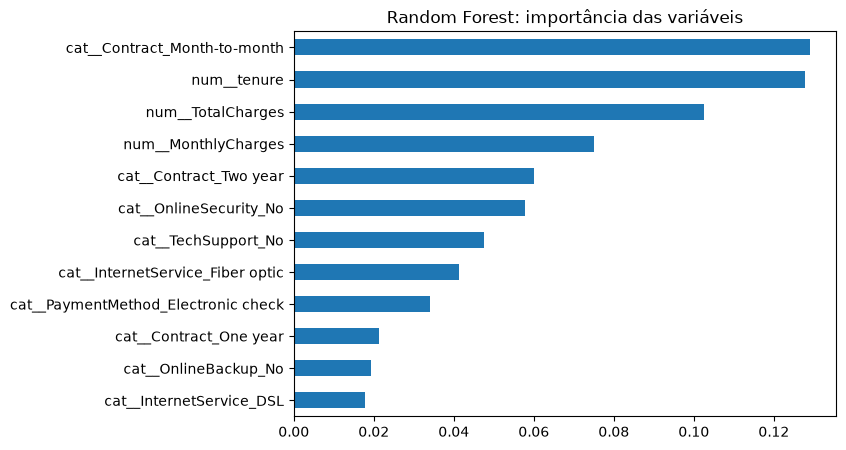

In [8]:
rf = modelos['Random Forest']
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=rf.named_steps['prep'].get_feature_names_out())
imp.sort_values().tail(12).plot.barh(figsize=(7, 5), title='Random Forest: importância das variáveis'); plt.show()